# Comparación de Posibles Modelos - AndesLink Churn

Este notebook tiene como objetivo experimentar con diferentes algoritmos de clasificación para predecir el churn de clientes. 
Se compararán:
1. **Logistic Regression** (Línea base)
2. **Random Forest** (Sugerido para estos casos)
3. **XGBoost** (Potencial modelo de alta performance)

**Foco principal:** Maximizar el **Recall** para la clase 1 (Churn).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score

from src.features.build_features import get_preprocessor

### 1. Carga de Datos y Configuración

### 1. Ingesta de Datos y División Estratégica (Split)

En esta primera etapa, preparamos el terreno para el modelado siguiendo buenas prácticas de MLOps:
* **Parametrización:** Extraemos variables clave (como el tamaño del set de prueba y la semilla aleatoria) directamente de nuestro archivo de configuración `params.yml`. Esto facilita la reproducibilidad del experimento.
* **Prevención de Ruido:** Basados en los hallazgos del EDA (Hito 1), eliminamos la columna `total_charges` para evitar problemas de multicolinealidad estructural.
* **Muestreo Estratificado:** Al dividir los datos en Entrenamiento (80%) y Prueba (20%), aplicamos `stratify=y`. Dado que nuestro dataset está desbalanceado (34% Churn), esto garantiza que ambos conjuntos mantengan exactamente la misma proporción de fuga, evitando sesgos en la evaluación.

In [15]:
# Cargar parámetros desde params.yml
with open('params.yaml', 'r') as f:
    params = yaml.safe_load(f)

target_col = params['prepare']['target_column']

# Cargar dataset
df = pd.read_csv('data/raw/churn_sintetico.csv')

# Eliminar total_charges por multicolinealidad (según hallazgos del Hito 1)
df = df.drop(columns=['total_charges'])

# Convertir columnas numéricas a float64 para evitar issues con missing values en MLflow
numeric_cols = df.select_dtypes(include=['int64']).columns
df[numeric_cols] = df[numeric_cols].astype('float64')

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=params['prepare']['test_size'],
    random_state=params['prepare']['random_state'],
    stratify=y
)

print(f"Dimensiones entrenamiento: {X_train.shape}")
print(f"Dimensiones prueba: {X_test.shape}")

Dimensiones entrenamiento: (4000, 14)
Dimensiones prueba: (1000, 14)


### 2. Preprocesamiento Seguro (Evitando Data Leakage)

Los algoritmos de Machine Learning requieren datos numéricos estandarizados. Para ello, utilizamos el motor de transformación modularizado en `src/features/build_features.py`:
* **Variables Numéricas:** Estandarización mediante `StandardScaler`.
* **Variables Categóricas:** Transformación mediante `OneHotEncoder`.

**Decisión Arquitectónica:** El preprocesador se integra dentro de un `Pipeline`. Esto asegura que las transformaciones se "aprendan" únicamente con los datos de entrenamiento, previniendo la fuga de información (Data Leakage) hacia el set de prueba.

In [16]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Uso del preprocesador oficial del proyecto
preprocessor = get_preprocessor(numeric_features, categorical_features)

### 3, 4 y 5 - Entrenamiento de Modelos, Evaluación y Optimización Orientados a Negocio

**Objetivo Estratégico:** Maximizar **Recall** para la clase 1 (Churn) para minimizar la fuga no detectada.

**Flujo de Experimentación:**
1. **Fase 1 (Sección 3-4):** Entrenar tres modelos base (Logistic Regression, Random Forest, XGBoost) con umbral estándar (0.5) para comparación inicial.
2. **Fase 2 (Sección 5):** Aplicar tuning al Random Forest usando `RandomizedSearchCV` optimizando específicamente para Recall.
3. **Fase 3 (Sección 5.1):** Analizar trade-off Precisión-Recall con el Random Forest optimizado para determinar el umbral de decisión más adecuado a la estrategia de negocio.

#### 3. Definición y Evaluación de Modelos Base (Umbral = 0.5)

In [17]:
def evaluate_model(model, name, X_train, X_test, y_train, y_test, threshold=0.5):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)

    # Obtener probabilidades y aplicar umbral personalizado
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    print(f"\n--- {name} (threshold={threshold}) ---")
    print(classification_report(y_test, y_pred))

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    return {
        'Model': name,
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }


--- Logistic Regression (threshold=0.5) ---
              precision    recall  f1-score   support

         0.0       0.82      0.64      0.72       660
         1.0       0.51      0.73      0.60       340

    accuracy                           0.67      1000
   macro avg       0.67      0.69      0.66      1000
weighted avg       0.72      0.67      0.68      1000



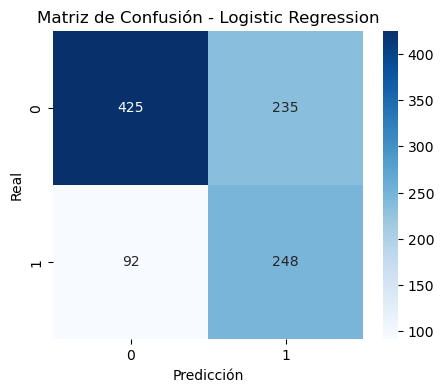


--- Random Forest (threshold=0.5) ---
              precision    recall  f1-score   support

         0.0       0.82      0.57      0.68       660
         1.0       0.48      0.76      0.59       340

    accuracy                           0.64      1000
   macro avg       0.65      0.67      0.63      1000
weighted avg       0.70      0.64      0.64      1000



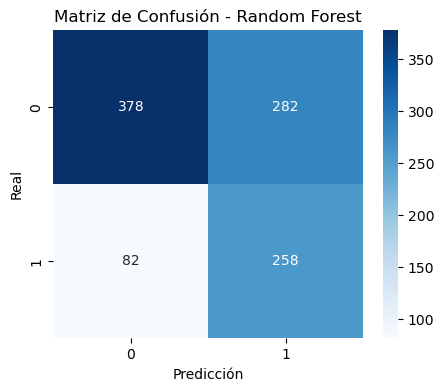


--- XGBoost (threshold=0.5) ---
              precision    recall  f1-score   support

         0.0       0.75      0.74      0.74       660
         1.0       0.51      0.51      0.51       340

    accuracy                           0.66      1000
   macro avg       0.63      0.63      0.63      1000
weighted avg       0.67      0.66      0.66      1000



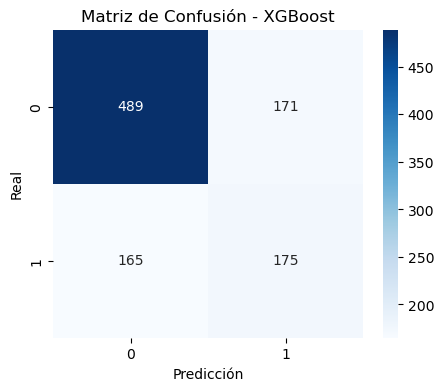

In [18]:
results = []

# 1. Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
results.append(evaluate_model(lr_model, "Logistic Regression", X_train, X_test, y_train, y_test))

# 2. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=params['train']['n_estimators'],
    max_depth=params['train']['max_depth'],
    class_weight=params['train'].get('class_weight', 'balanced'),
    random_state=params['train']['random_state']
)
results.append(evaluate_model(rf_model, "Random Forest", X_train, X_test, y_train, y_test))

# 3. XGBoost
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)
results.append(evaluate_model(xgb_model, "XGBoost", X_train, X_test, y_train, y_test))

#### 4. Comparación de Métricas Base (Umbral = 0.5)

                 Model    Recall  Precision  F1-Score   ROC-AUC
1        Random Forest  0.758824   0.477778  0.586364  0.740348
0  Logistic Regression  0.729412   0.513458  0.602673  0.757496
2              XGBoost  0.514706   0.505780  0.510204  0.699153


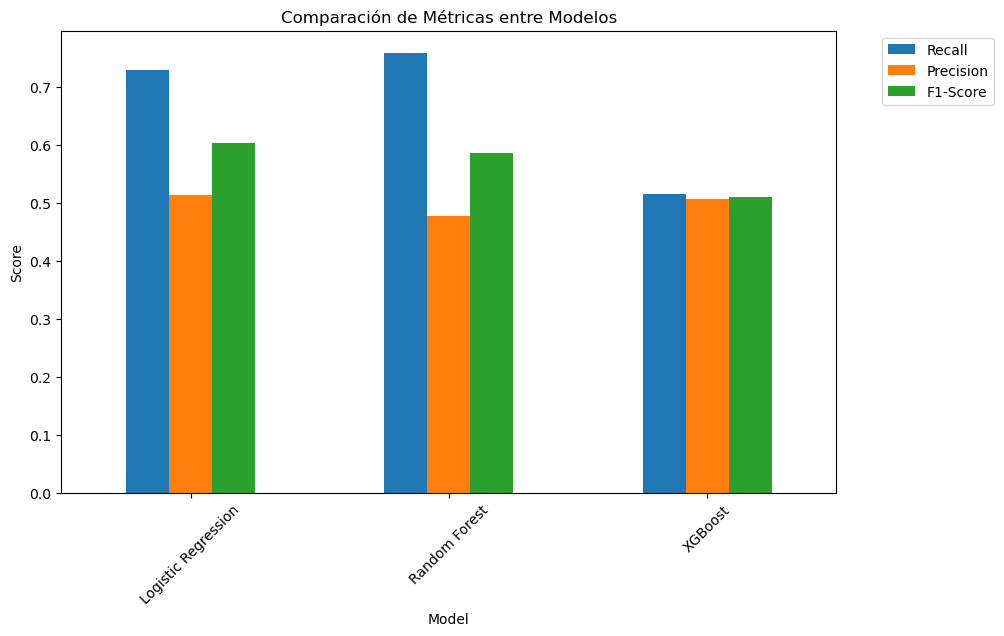

In [19]:
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='Recall', ascending=False))

results_df.set_index('Model')[['Recall', 'Precision', 'F1-Score']].plot(kind='bar', figsize=(10, 6))
plt.title('Comparación de Métricas entre Modelos')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### 5. Optimización de Hiperparámetros (Tuning) y Análisis de Trade-off


🎯 RESULTADOS DE OPTIMIZACIÓN
Mejor Recall (5-fold CV): 0.7797

📋 Mejores Hiperparámetros Encontrados:
------------------------------------------------------------
  • n_estimators        : 50              (Cantidad de árboles en el bosque)
  • min_samples_split   : 10              (Mínimo de muestras para dividir un nodo)
  • min_samples_leaf    : 1               (Mínimo de muestras en cada hoja)
  • max_depth           : 5               (Profundidad máxima de cada árbol)
  • bootstrap           : False           (Usar muestreo con reemplazo para entrenar)


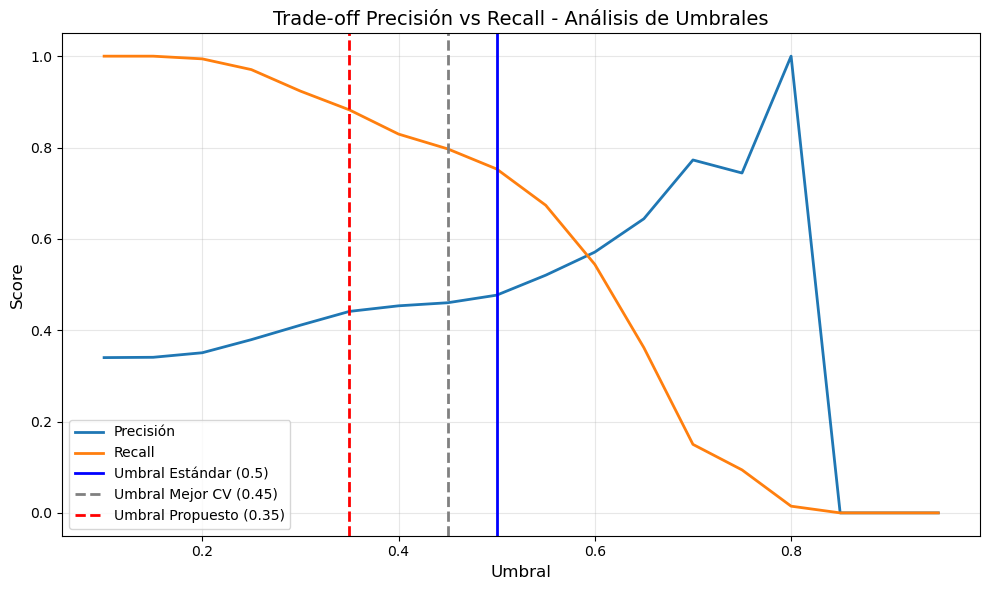


📊 Análisis de Umbrales:
   • Umbral Estándar (0.5): Recall Test=0.7529 | Precision Test=0.4767
   • Umbral Mejor CV (0.45): Recall Test=0.7971 | Precision Test=0.4601 | Recall CV=0.7797
   • Umbral Propuesto (0.35): Recall Test=0.8824 | Precision Test=0.4412


In [ ]:

# Configuración de la búsqueda
param_dist = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__max_depth': [None, 5, 10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

# Extraer parámetros sin prefijo 'classifier__'
best_params_clean = {k.replace('classifier__', ''): v for k, v in random_search.best_params_.items()}

print("\n RESULTADOS DE OPTIMIZACIÓN")
print("=" * 60)
print(f"Mejor Recall (5-fold CV): {random_search.best_score_:.4f}")
print("\n Mejores Hiperparámetros Encontrados:")
print("-" * 60)
for param, value in best_params_clean.items():
    param_descriptions = {
        'n_estimators': 'Cantidad de árboles en el bosque',
        'max_depth': 'Profundidad máxima de cada árbol',
        'min_samples_split': 'Mínimo de muestras para dividir un nodo',
        'min_samples_leaf': 'Mínimo de muestras en cada hoja',
        'bootstrap': 'Usar muestreo con reemplazo para entrenar'
    }
    description = param_descriptions.get(param, '')
    print(f"  • {param:20s}: {str(value):15s} ({description})")
print("=" * 60)

best_rf = random_search.best_estimator_
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

# Guardar el mejor Recall del CV
best_recall_cv = random_search.best_score_

# Análisis de umbrales
thresholds = np.arange(0.1, 1.0, 0.05)
precisions = []
recalls = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_best >= threshold).astype(int)
    precisions.append(precision_score(y_test, y_pred_threshold, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_threshold, zero_division=0))

# Encontrar el umbral que produce un Recall más cercano a best_recall_cv en el test set
recalls_array = np.array(recalls)
best_recall_idx = np.argmin(np.abs(recalls_array - best_recall_cv))
best_recall_threshold = thresholds[best_recall_idx]
best_recall_test = recalls_array[best_recall_idx]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precisión', linewidth=2)
plt.plot(thresholds, recalls, label='Recall', linewidth=2)
plt.axvline(x=0.5, color='blue', linestyle='-', linewidth=2, label='Umbral Estándar (0.5)')
plt.axvline(x=best_recall_threshold, color='gray', linestyle='--', linewidth=2, label=f'Umbral Mejor CV ({best_recall_threshold:.2f})')
plt.axvline(x=0.35, color='red', linestyle='--', linewidth=2, label='Umbral Propuesto (0.35)')
plt.xlabel('Umbral', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Trade-off Precisión vs Recall - Análisis de Umbrales', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Índices para cada umbral
idx_05 = np.argmin(np.abs(thresholds - 0.5))
idx_035 = np.argmin(np.abs(thresholds - 0.35))

print(f"\n Análisis de Umbrales:")
print(f"   • Umbral Estándar (0.5): Recall Test={recalls[idx_05]:.4f} | Precision Test={precisions[idx_05]:.4f}")
print(f"   • Umbral Mejor CV ({best_recall_threshold:.2f}): Recall Test={best_recall_test:.4f} | Precision Test={precisions[best_recall_idx]:.4f} | Recall CV={best_recall_cv:.4f}")
print(f"   • Umbral Propuesto (0.35): Recall Test={recalls[idx_035]:.4f} | Precision Test={precisions[idx_035]:.4f}")


### Análisis de Resultados y Selección del Modelo Definitivo

Tras la optimización, el **Random Forest** con un umbral ajustado (~0.35) permite maximizar el Recall y mantener un valor estable de Precision. Con estos valores podemos mejorar el objetivo de AndesLink de minimizar la fuga no detectada.

### Trazabilidad y Empaquetamiento del Modelo (MLflow)

Registramos el experimento y el modelo oficial en la base de datos central de MLflow.

In [ ]:
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
import joblib
from pathlib import Path
import os
import warnings

# Mitigar warning de OpenMP conflictante
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# Suprimir warning de artifact_path deprecado en MLflow
warnings.filterwarnings('ignore', message='.*artifact_path.*', category=Warning)

# Obtener la ruta absoluta del proyecto (carpeta raíz)
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

mlflow_db_path = project_root / "mlflow.db"
models_dir = project_root / "models"

# Crear directorios si no existen
models_dir.mkdir(exist_ok=True)

# Configurar Tracking URI con ruta absoluta
mlflow.set_tracking_uri(f"sqlite:///{mlflow_db_path}")
mlflow.set_experiment("AndesLink_Churn_Prediction")

with mlflow.start_run(run_name="Optimized_Random_Forest"):
    mlflow.log_params(random_search.best_params_)

    y_pred_final = (y_proba_best >= 0.35).astype(int)

    mlflow.log_metrics({
        "recall": recall_score(y_test, y_pred_final),
        "precision": precision_score(y_test, y_pred_final),
        "f1": f1_score(y_test, y_pred_final)
    })

    # Usar input_example del conjunto de prueba para mejor representación
    input_example = X_test.iloc[:5].copy()
    signature = infer_signature(X_test, y_pred_final)

    # Log model using skops format (safer than pickle)
    mlflow.sklearn.log_model(
        best_rf,
        "model",
        signature=signature,
        serialization_format="skops",
        input_example=input_example
    )

    # Guardar localmente en formato pickle para compatibilidad
    model_path = models_dir / "model.pkl"
    joblib.dump(best_rf, model_path)
    print(f" Modelo guardado exitosamente en {model_path}")


2026/05/11 11:23:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Modelo guardado exitosamente en c:\andeslink-churn\models\model.pkl
